# **Survival Analisys: Czas oczekiwania na płatność**
## Big Enterprises vs Small and Medium Enterprises

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import lifelines as ll

data = pd.read_csv('../data/dataset_survival.csv')

In [25]:
kmf_be = ll.KaplanMeierFitter()
kmf_sme = ll.KaplanMeierFitter()

be_data = data[data['segment'] == 'BE']
sme_data = data[data['segment'] == 'SME']

kmf_be.fit(be_data['time_days'], event_observed=be_data['event'], label='BE')
kmf_sme.fit(sme_data['time_days'], event_observed=sme_data['event'], label='SME')

<lifelines.KaplanMeierFitter:"SME", fitted with 7801 total observations, 1320 right-censored observations>

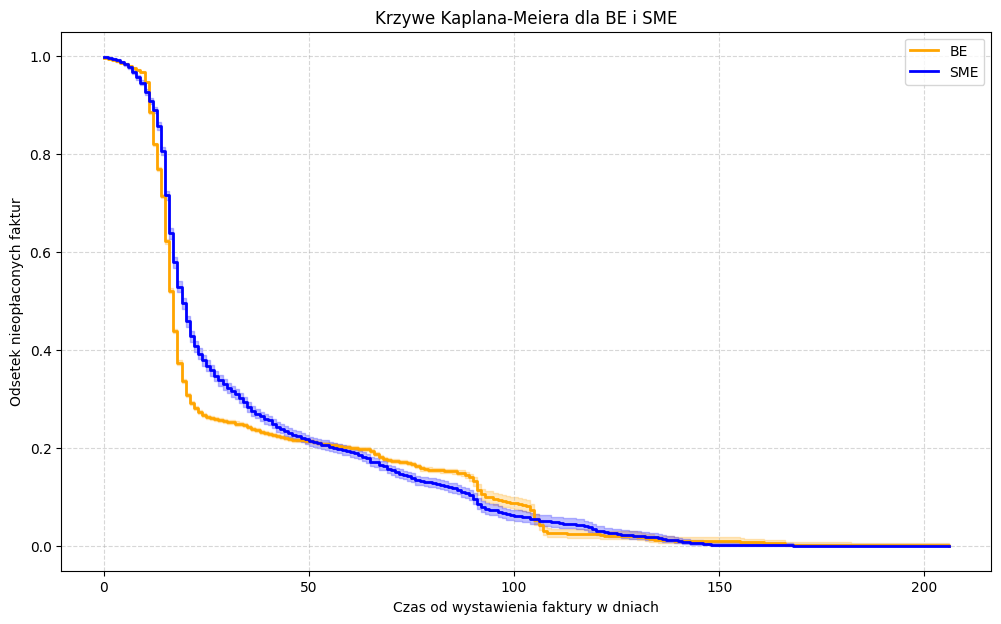

In [26]:
plt.figure(figsize=(12,7))

kmf_be.plot_survival_function(ci_show=True, color='orange', linewidth=2)
kmf_sme.plot_survival_function(ci_show=True, color='blue', linewidth=2)

plt.title('Krzywe Kaplana-Meiera dla BE i SME')
plt.xlabel('Czas od wystawienia faktury w dniach')
plt.ylabel('Odsetek nieopłaconych faktur')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [31]:
results = ll.statistics.logrank_test(be_data['time_days'], sme_data['time_days'], event_observed_A=be_data['event'], event_observed_B=sme_data['event'])

if results.p_value < 0.05:
    print('Różnica jest istotna statystycznie')
else:
    print('Brak istotnych różnic w czasie płatności')

Różnica jest istotna statystycznie
